In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','beta','beta_v2')

In [3]:
GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))

In [4]:
dir_data = os.path.join(dir_base,'ITALY_Beta_GSMaP_3h_2002_2023_npix_2.nc')
DATA = xr.open_dataset(dir_data)

lon2d, lat2d = np.meshgrid(DATA['lon'].values, DATA['lat'].values)

BETA2 = DATA['BETA'].values

In [5]:
dir_data = os.path.join(dir_base,'ITALY_Beta_GSMaP_3h_2002_2023_npix_3.nc')
DATA = xr.open_dataset(dir_data)

BETA3 = DATA['BETA'].values

In [6]:
dir_data = os.path.join(dir_base,'ITALY_Beta_GSMaP_3h_2002_2023_npix_4.nc')
DATA = xr.open_dataset(dir_data)

BETA4 = DATA['BETA'].values

In [7]:
BETA_norm = None
BETA_cmap = plt.cm.Spectral_r

Text(0.0, 1.0, '(c) Beta 4')

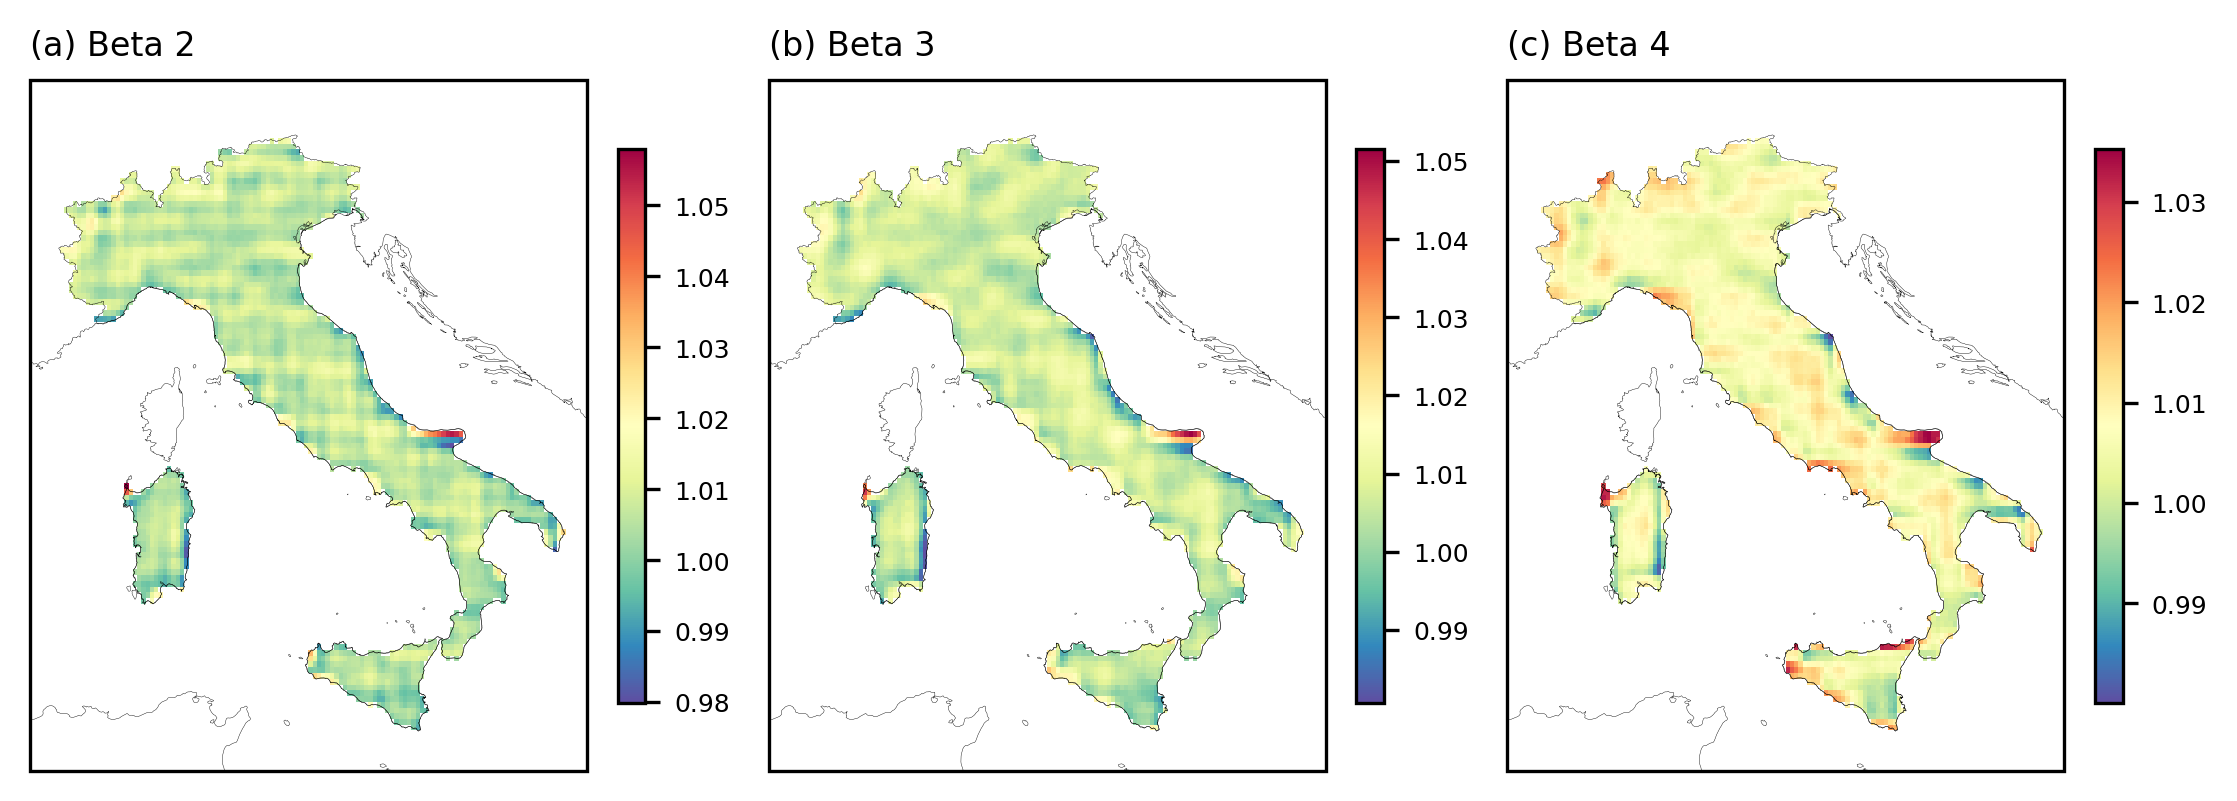

In [8]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
# ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA2, norm=BETA_norm, cmap=BETA_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) Beta 2', fontsize=8, loc='left')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
# ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA3, norm=BETA_norm, cmap=BETA_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) Beta 3', fontsize=8, loc='left')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
# ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA4, norm=BETA_norm, cmap=BETA_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(c) Beta 4', fontsize=8, loc='left')

In [9]:
BETA2_list = BETA2[~np.isnan(BETA2)]
BETA3_list = BETA3[~np.isnan(BETA3)]
BETA4_list = BETA4[~np.isnan(BETA4)]

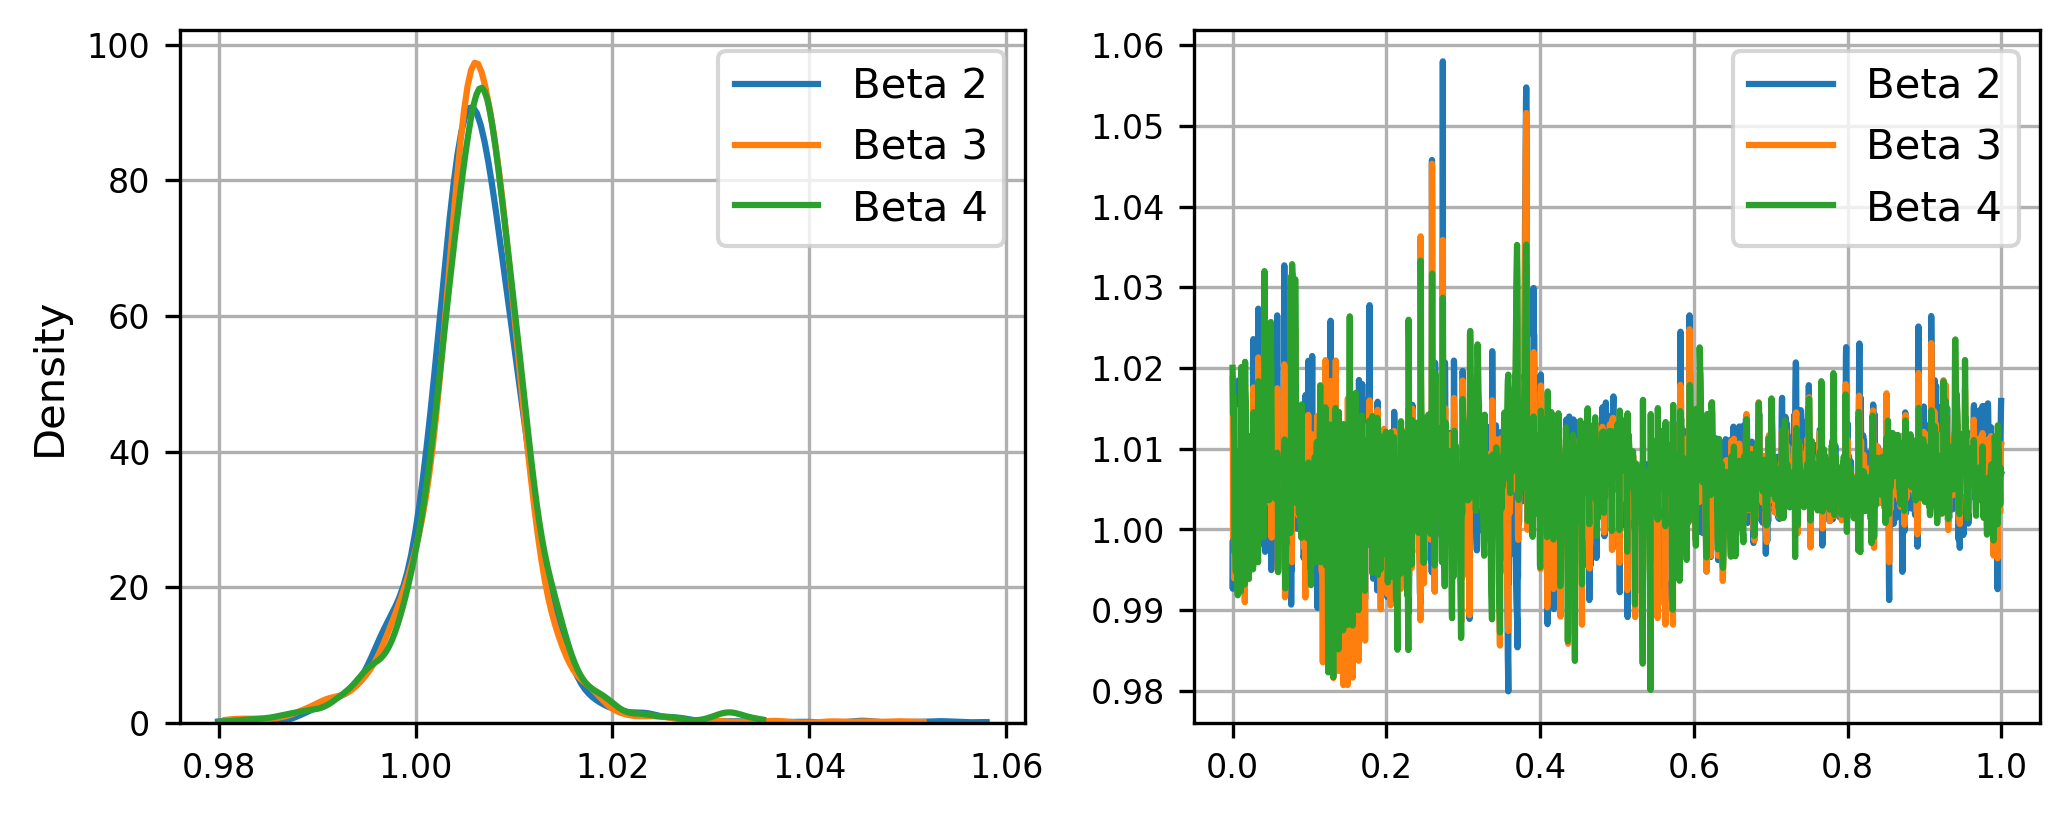

In [10]:
fig = plt.figure(figsize=(8,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])

sns.kdeplot(BETA2_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Beta 2',
            clip=(np.nanmin(np.array(BETA2_list)), np.nanmax(np.array(BETA2_list))))

sns.kdeplot(BETA3_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Beta 3',
            clip=(np.nanmin(np.array(BETA3_list)), np.nanmax(np.array(BETA3_list))))

sns.kdeplot(BETA4_list,cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'Beta 4',
            clip=(np.nanmin(np.array(BETA4_list)), np.nanmax(np.array(BETA4_list))))

ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])

ax1.plot(np.arange(len(BETA2_list))/len(BETA2_list), BETA2_list, label=f'Beta 2')
ax1.plot(np.arange(len(BETA3_list))/len(BETA3_list), BETA3_list, label=f'Beta 3')
ax1.plot(np.arange(len(BETA4_list))/len(BETA4_list), BETA4_list, label=f'Beta 4')

ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=8)